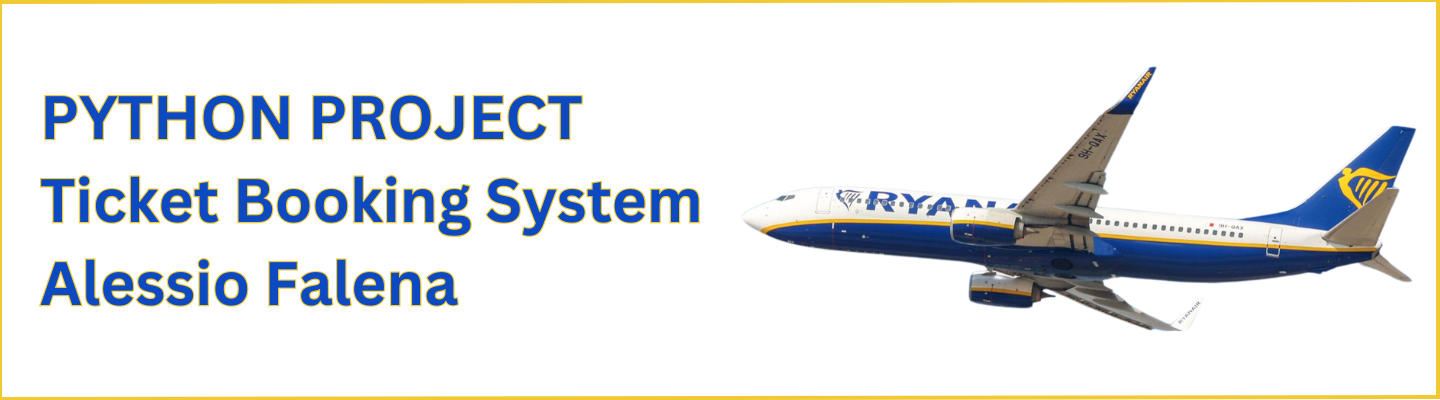

<div style="background-color: #f1c933; color:#0d49c0; border: 2px solid #0d49c0; font-size: 15px; padding: 10px;">
    <span style="font-size: 30px;"><b>Table of Contents</b></span><br><br>

<b>0. Introduction</b><br>
<b>1. register_new_ticket()</b><br>
<b>2. generate_multiple_random_tickets(n)</b><br>
<b>3. show_registered_tickets()</b><br>
<b>4. search_ticket_interactive()</b><br>
<b>5. show_ticket_statistics()</b><br>
<b>6. search_ticket_by_multiple_attributes()</b>
</div>


<div style="background-color: #0d49c0; color: white;border: 2px solid #f1c933; font-size: 15px; padding: 10px;">
<span style="font-size: 30px;"><b>0) Introduction</b></span>

This project was developed during the Python module of the Data Analysis course by Start2Impact.  
The assignment required the creation of an element management system that allows the user to perform various actions. These include registering a new element, viewing all registered elements, generating statistics on the elements and their attributes, searching for a specific element using a single attribute as a filter, and conducting an advanced search using multiple attributes as filters.  
I chose to create a management system for the sale of airline tickets for a flight. I stayed as faithful as possible to the variables involved in the purchase process on the official website of the airline Ryanair.
</div> 

<div style="background-color: #0d49c0; color: white;border: 2px solid #f1c933; font-size: 15px; padding: 10px;">
<span style="font-size: 30px;"><b>1) register_new_ticket() function</b></span>

In [1]:
from datetime import datetime
import random
from IPython.display import clear_output

available_seats = ["01A", "01B", "01C", "02A", "02B", "02C", "02D", "02E", "02F", "03A", "03B", "03C", 
                           "03D", "03E", "03F", "04A", "04B", "04C", "04D", "04E", "04F", "05A", "05B", "05C", 
                           "05D", "05E", "05F", "06A", "06B", "06C", "06D", "06E", "06F", "07A", "07B", "07C", 
                           "07D", "07E", "07F", "08A", "08B", "08C", "08D", "08E", "08F", "09A", "09B", "09C", 
                           "09D", "09E", "09F", "10A", "10B", "10C", "10D", "10E", "10F", "11A", "11B", "11C", 
                           "11D", "11E", "11F", "12A", "12B", "12C", "12D", "12E", "12F", "13A", "13B", "13C", 
                           "13D", "13E", "13F", "14A", "14B", "14C", "14D", "14E", "14F", "15A", "15B", "15C", 
                           "15D", "15E", "15F", "16A", "16B", "16C", "16D", "16E", "16F", "17A", "17B", "17C", 
                           "17D", "17E", "17F", "18A", "18B", "18C", "18D", "18E", "18F", "19A", "19B", "19C", 
                           "19D", "19E", "19F", "20A", "20B", "20C", "20D", "20E", "20F", "21A", "21B", "21C", 
                           "21D", "21E", "21F", "22A", "22B", "22C", "22D", "22E", "22F", "23A", "23B", "23C", 
                           "23D", "23E", "23F", "24A", "24B", "24C", "24D", "24E", "24F", "25A", "25B", "25C", 
                           "25D", "25E", "25F", "26A", "26B", "26C", "26D", "26E", "26F", "27A", "27B", "27C", 
                           "27D", "27E", "27F", "28A", "28B", "28C", "28D", "28E", "28F", "29A", "29B", "29C", 
                           "29D", "29E", "29F", "30A", "30B", "30C", "30D", "30E", "30F", "31A", "31B", "31C", 
                           "31D", "31E", "31F", "32A", "32B", "32C", "32D", "32E", "32F", "33A", "33B", "33C", 
                           "33D", "33E", "33F"]

registered_tickets = []

def register_new_ticket(available_seats, registered_tickets): 
    """ Registers a new ticket based on user input and updates available seats and registered tickets.
    
    This function takes as parameters the lists available_seats and registered_tickets, which are necessary 
    for correctly managing seat assignment for each newly registered ticket.
    The function is divided into parts to make it easier to read and understand.
    It handles the process in which the user inputs a new ticket by providing the passenger's name,
    the type of ticket, the seat, etc. """


    #---------------------------PART OF THE FUNCTION THAT COLLECTS THE INITIAL PASSENGER INFORMATION--------------------------------------
    
    passenger_name = input("What is the name of the passenger? ").casefold().strip() #Get passenger name from user input
    
    purchase_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S") #Use datetime library to record timestamp of purchase  

    valid_ticket_types = {
    "1": "basic",
    "2": "regular",
    "3": "plus",
    "4": "flexiplus"}

    print("Ticket types:") #Shows ticket types to the user
    for key, value in valid_ticket_types.items():
        print(f"{key} - {value.capitalize()}")
    
    ticket_choice = input(f"Enter the number corresponding to {passenger_name}'s ticket type: ").strip() 
    #Prompt user for ticket type

    while ticket_choice not in valid_ticket_types:
        print("Invalid input. Please enter a number from 1 to 4.")
        ticket_choice = input(f"Enter the number corresponding to {passenger_name}'s ticket type: ").strip()
    #Use while loop to validate input until it's correct

    ticket_type = valid_ticket_types[ticket_choice] #Assign the correct ticket type 
    
    #-------------------------------PART OF THE FUNCTION THAT HANDLES SEAT ASSIGNMENT------------------------------------------
    
    reserved_seat = None  
    seat_removed = False 

    if ticket_type == "basic": #Seat assignment if ticket is Basic
        while True:
            print(f"\nDoes {passenger_name} want to choose the seat?")  #Ask if user wants to choose a seat
            print("1 - Yes")
            print("2 - No")
            seat_choice = input("Enter 1 for Yes or 2 for No: ").strip()

            if seat_choice == "1":
                choose_seat = "yes"
                break
            elif seat_choice == "2":
                choose_seat = "no"
                break
            else:
                print("Invalid input. Please enter 1 or 2.")
        

        if choose_seat == "yes":                                                          
            print("Please choose an available seat from the list of unassigned seats.") #Display available seats and prompt for selection
            print("Available seats:", available_seats)
            chosen_seat = input("Choose your seat: ").upper().strip()
            
            while chosen_seat not in available_seats: #Use while loop to validate seat choice
                print("Invalid seat or seat already assigned. Please choose a different seat.") 
                print("Available seats:", available_seats) 
                chosen_seat = input("Choose your seat: ").upper().strip() 
          
       
            available_seats.remove(chosen_seat)
            seat_removed = True
            reserved_seat = chosen_seat
            print(f"Seat {chosen_seat} has been assigned to {passenger_name}.")

        else:  
            if not available_seats: 
                print("Sorry, there are no seats available for random assignment.")
                return 
            assigned_seat = random.choice(available_seats) #Assign a random seat
            available_seats.remove(assigned_seat)
            seat_removed = True
            reserved_seat = assigned_seat
            print(f"Seat {reserved_seat} has been randomly assigned to {passenger_name}.")
    
    else: #Seat assignment if ticket is Regular, Plus, Flexiplus
        if not available_seats: 
                print("Sorry, there are no seats available.")
                return 
        print("Please choose an available seat from the list of unassigned seats.")
        print("Available seats:", available_seats)
        
        chosen_seat = input(f"Choose your seat for {passenger_name}: ").upper().strip()

        while chosen_seat not in available_seats:
            print("Invalid seat or seat already assigned. Please choose a different seat.")
            print("Available seats:", available_seats) 
            chosen_seat = input(f"Choose your seat for {passenger_name}: ").upper().strip()
        
       
        available_seats.remove(chosen_seat)
        seat_removed = True
        reserved_seat = chosen_seat
        print(f"Seat {chosen_seat} has been assigned to {passenger_name}.")

    #-------------------------------PART OF THE FUNCTION THAT HANDLES DUPLICATES------------------------------------------
    
    is_duplicate = False 
    for existing_ticket in registered_tickets:
        if existing_ticket["Passenger Name"].casefold() == passenger_name.casefold() and \
           existing_ticket["Reserved Seat"] == reserved_seat:
            is_duplicate = True
            break

    if is_duplicate:
        print(f"\nError: A ticket for {passenger_name} in seat {reserved_seat} already exists.")
        print("Registration cancelled.")
        if seat_removed and reserved_seat:
            available_seats.append(reserved_seat) 
        return #Exits the function to avoid adding the duplicate
        

    #-------------------------------PART OF THE FUNCTION THAT HANDLES THE FAST TRACK OPTION-------------------------------
    
    if ticket_type == "flexiplus": #Assign fast track automatically for Flexiplus tickets
        fast_track = "yes"
    else: #Prompt user for fast track option
        while True:
            print(f"\nDoes {passenger_name} want fast track?")
            print("1 - Yes")
            print("2 - No")
                
            fast_track_choice = input("Enter 1 for Yes or 2 for No: ").strip()
            if fast_track_choice == "1":
                fast_track = "yes"
                break
            elif fast_track_choice == "2":
                fast_track = "no"
                break
            else:
                print("Invalid input. Please enter 1 or 2.")


    #---------------------------PART OF THE FUNCTION THAT HANDLES PRIORITY BOARDING & CABIN BAG---------------------------
    
    if ticket_type in ["regular", "flexiplus"]: #Set default options for Regular and Flexiplus tickets 
        ten_kg_cabin_bags = 1
        priority_boarding = "yes"
    else: #Other tickets users ask if they want priority and 10kg cabin bag
        while True:
            print(f"\nDoes {passenger_name} want priority & 10kg cabin bag?")
            print("1 - Yes")
            print("2 - No")
            extra_option_choice = input("Enter 1 for Yes or 2 for No: ").strip()
            
            if extra_option_choice == "1":
                ten_kg_cabin_bags = 1
                priority_boarding = "yes"
                break
            elif extra_option_choice == "2":
                ten_kg_cabin_bags = 0
                priority_boarding = "no"
                break
            else:
                print("Invalid input. Please enter 1 or 2.")

    #--------------------------------PART OF THE FUNCTION THAT HANDLES 10KG CHECK-IN BAG-----------------------------------
    
    while True:
        print(f"\nDoes {passenger_name} want a 10kg check-in bag?")
        print("1 - Yes")
        print("2 - No")
        check_in_bag_10kg_choice = input("Enter 1 for Yes or 2 for No: ").strip()
        
        if check_in_bag_10kg_choice == "1":
            check_in_bag_10kg = 1
            break
        elif check_in_bag_10kg_choice == "2":
            check_in_bag_10kg = 0
            break
        else:
            print("❌ Invalid input. Please enter 1 or 2.")

    #--------------------------------PART OF THE FUNCTION THAT HANDLES 20KG CHECK-IN BAG-----------------------------------
            
    if ticket_type == "plus": #Plus always include a 20kg bag                                                                           
        check_in_bags_20kg = 1 
        while True:
            additional_bags = input(f"{passenger_name} already has 1 x 20kg bag included. Add more (0-2)? ").strip()
            if additional_bags.isdigit() and 0 <= int(additional_bags) <= 2:
                check_in_bags_20kg += int(additional_bags)  
                break 
            print("Invalid input. Please enter a number between 0 and 2.") 
    else: #For tickets of type Basic, Regular, Flexiplus
        while True:
            check_in_bags_20kg_input = input(f"How many 20kg check-in bags does {passenger_name} want? (0-3): ").strip()
            if check_in_bags_20kg_input.isdigit() and 0 <= int(check_in_bags_20kg_input) <= 3:
                check_in_bags_20kg = int(check_in_bags_20kg_input)
                break 
            print("Invalid input. Please enter a number between 0 and 3.")

    #PART OF THE FUNCTION THAT CREATE THE TICKET, APPEND IT TO REGISTERED_TICKETS AND CLEAR THE PREVIOUS OUTPUT-----------
    
    ticket = {
        "Passenger Name": passenger_name,
        "Purchase Date": purchase_datetime,
        "Ticket Type": ticket_type,
        "Reserved Seat": reserved_seat,
        "Fast Track": fast_track,
        "10kg Cabin Bags": ten_kg_cabin_bags, 
        "Priority Boarding": priority_boarding,
        "10kg Check-in Bag": check_in_bag_10kg, 
        "20kg Check-in Bags": check_in_bags_20kg
    }
    registered_tickets.append(ticket) 
    
    clear_output(wait=True) #Clear the previous output 
    print("Ticket successfully registered!")
    for key, value in ticket.items():
        print(f"{key}: {value}")

In [2]:
register_new_ticket(available_seats, registered_tickets)

Ticket successfully registered!
Passenger Name: alessio
Purchase Date: 2025-04-13 17:15:18
Ticket Type: basic
Reserved Seat: 12A
Fast Track: yes
10kg Cabin Bags: 1
Priority Boarding: yes
10kg Check-in Bag: 0
20kg Check-in Bags: 0


In [3]:
register_new_ticket(available_seats, registered_tickets)

Ticket successfully registered!
Passenger Name: andrea
Purchase Date: 2025-04-13 17:15:55
Ticket Type: flexiplus
Reserved Seat: 01A
Fast Track: yes
10kg Cabin Bags: 1
Priority Boarding: yes
10kg Check-in Bag: 1
20kg Check-in Bags: 0


<div style="background-color: #0d49c0; color: white;border: 2px solid #f1c933; font-size: 15px; padding: 10px;">
    <span style="font-size: 30px;"><b>2) generate_multiple_random_tickets(n) function</b></span>
</div>

In [4]:
import random
from datetime import datetime

def generate_random_ticket(registered_tickets, available_seats):
    
    """
    Generate a new random ticket.
    
    It takes registered_tickets and available_seats as parameters to avoid creating duplicates.
    It stores all possible options for each ticket attribute in lists. 
    It then uses the random library to randomly select values from these lists, creating a simulated ticket. 
    """

    passenger_names = [
    "Luca Bianchi", "Sophie Dubois", "Marta Nowak", "Johan Eriksson", "Miguel Fernández", "Elena Rossi",
    "Dominik Kovács", "Petra Horváth", "Filip Jovanović", "Ivana Petrović", "Niels Christensen", "Anna Müller",
    "Rafał Kowalski", "Lucie Moreau", "Giovanni Conti", "Emma Schneider", "Stefan Popescu", "Andreea Ionescu",
    "Hans Fischer", "Marie Lambert", "Erik Karlsson", "Katarina Novak", "Boris Ivanov", "Elisabeth Bauer",
    "Matej Kovač", "Jasmin Meier", "Daan De Vries", "Monika Szabó", "Pavel Sokolov", "Lena Weber",
    "Hugo Lefebvre", "Daniel Németh", "Ines Almeida", "Antonio Romano", "Therese Gustafsson", "Kristian Hansen",
    "Ewa Malinowska", "Carlos Silva", "Nina Dimitrova", "Valentin Lefevre", "Jürgen Hoffmann", "Ana Costa",
    "Viktor Pavlov", "Maja Stojanović", "Marc Dubois", "Jakub Novák", "Henrik Nielsen", "Lucia Ferrari",
    "Jorge Mendes", "Katerina Apostolou", "René Dupont", "Sebastian Braun", "Alina Popa", "Tomasz Wójcik",
    "Ludovic Bernard", "Adriana Vasile", "Francesco Ricci", "Paula Martins", "Niko Mäkinen", "Eva Schmidt",
    "Filippo De Luca", "Maria Castro", "Stéphane Morel", "Dario Müller", "Sigrid Andersen", "Hanna Olsson",
    "Leonid Smirnov", "Jelena Marković", "Christian Richter", "Helena Svensson", "Olivier Laurent", "Natalia Nowicka",
    "Konstantinos Papadopoulos", "Stefan Müller", "Martina Klein", "Jonas Wolf", "Giulia Lombardi", "Olga Ivanova",
    "Peter Horvath", "Marco Benedetti", "Clara Dupuis", "Elias Martens", "Eliska Novakova", "Aleksi Virtanen",
    "Paul Keller", "Emilia Berger", "Ruben van Dijk", "Kristina Mladenović", "Szymon Kamiński", "Anna Karlsson",
    "Christophe Girard", "Domenico Russo", "Hanna Petrov", "Kristóf Szabó", "Sven Schneider", "Melanie Jansen",
    "Lars Møller"
] 

    
    ticket_types = ["basic", "regular", "plus", "flexiplus"]
    fast_track_options = ["yes", "no"]
    priority_boarding_options = ["yes", "no"]
    seat_list = available_seats  


    if not available_seats: #Prevents errors if there are no seats left
        print("No seats available. Cannot generate ticket.")
        return

    #They generate a random ticket and assign it a seat
    passenger_name = random.choice(passenger_names)
    ticket_type = random.choice(ticket_types)
    reserved_seat = random.choice(seat_list)
    available_seats.remove(reserved_seat) 

    #We declare the ticket variables
    if ticket_type == "flexiplus":
        fast_track = "yes"
    else:
        fast_track = random.choice(fast_track_options)

    priority_boarding = random.choice(priority_boarding_options)

    ten_kg_cabin_bags = random.choice([0, 1])
    check_in_bag_10kg = random.choice([0, 1])
    check_in_bags_20kg = random.randint(0, 3) if ticket_type == "plus" else random.randint(0, 1)

    #We declare the ticket dictionary.
    ticket = {
        "Passenger Name": passenger_name,
        "Purchase Date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Ticket Type": ticket_type,
        "Reserved Seat": reserved_seat,
        "Fast Track": fast_track,
        "10kg Cabin Bags": ten_kg_cabin_bags,
        "Priority Boarding": priority_boarding,
        "10kg Check-in Bag": check_in_bag_10kg,
        "20kg Check-in Bags": check_in_bags_20kg
    }

    
    registered_tickets.append(ticket) #Adds the new ticket to registered_tickets.
    print(f"Ticket generated for {passenger_name} ({ticket_type}) with seat {reserved_seat}.\n")

    #Using a for loop, it generates n tickets by nesting the previous function inside it.
def generate_multiple_random_tickets(registered_tickets, available_seats, n):  
    """Generates multiple random tickets."""
    for i in range(n):
        generate_random_ticket(registered_tickets, available_seats)

In [6]:
generate_multiple_random_tickets(registered_tickets, available_seats, 15)

Ticket generated for Anna Karlsson (flexiplus) with seat 02D.

Ticket generated for Henrik Nielsen (flexiplus) with seat 06E.

Ticket generated for Lucie Moreau (flexiplus) with seat 28C.

Ticket generated for Sophie Dubois (basic) with seat 30A.

Ticket generated for Christian Richter (plus) with seat 08A.

Ticket generated for Rafał Kowalski (plus) with seat 08D.

Ticket generated for Helena Svensson (flexiplus) with seat 11A.

Ticket generated for Helena Svensson (regular) with seat 17D.

Ticket generated for Boris Ivanov (basic) with seat 22B.

Ticket generated for Petra Horváth (plus) with seat 08E.

Ticket generated for Domenico Russo (regular) with seat 15F.

Ticket generated for Kristóf Szabó (flexiplus) with seat 27A.

Ticket generated for Emma Schneider (basic) with seat 23B.

Ticket generated for Miguel Fernández (basic) with seat 25D.

Ticket generated for Clara Dupuis (flexiplus) with seat 12F.



<div style="background-color: #0d49c0; color: white;border: 2px solid #f1c933; font-size: 15px; padding: 10px;">
    <span style="font-size: 30px;"><b>3) show_registered_tickets() function</b></span>
</div> 

In [7]:
def show_registered_tickets(registered_tickets):
    """Print all the registered tickets"""
    if not registered_tickets:
        print("No tickets registered yet.")
        return

    print("\nREGISTERED TICKETS:\n")
    for i, ticket in enumerate(registered_tickets, start=1):  
        print(f"Ticket {i}:")
        for key, value in ticket.items():
            print(f"{key}: {value}")
        print("-" * 40)

In [8]:
show_registered_tickets(registered_tickets)


REGISTERED TICKETS:

Ticket 1:
Passenger Name: alessio
Purchase Date: 2025-04-13 17:15:18
Ticket Type: basic
Reserved Seat: 12A
Fast Track: yes
10kg Cabin Bags: 1
Priority Boarding: yes
10kg Check-in Bag: 0
20kg Check-in Bags: 0
----------------------------------------
Ticket 2:
Passenger Name: andrea
Purchase Date: 2025-04-13 17:15:55
Ticket Type: flexiplus
Reserved Seat: 01A
Fast Track: yes
10kg Cabin Bags: 1
Priority Boarding: yes
10kg Check-in Bag: 1
20kg Check-in Bags: 0
----------------------------------------
Ticket 3:
Passenger Name: Marc Dubois
Purchase Date: 2025-04-13 17:16:39
Ticket Type: flexiplus
Reserved Seat: 06D
Fast Track: yes
10kg Cabin Bags: 1
Priority Boarding: no
10kg Check-in Bag: 0
20kg Check-in Bags: 0
----------------------------------------
Ticket 4:
Passenger Name: Nina Dimitrova
Purchase Date: 2025-04-13 17:16:39
Ticket Type: plus
Reserved Seat: 08B
Fast Track: no
10kg Cabin Bags: 0
Priority Boarding: yes
10kg Check-in Bag: 0
20kg Check-in Bags: 2
--------

<div style="background-color: #0d49c0; color: white;border: 2px solid #f1c933; font-size: 15px; padding: 10px;">
<span style="font-size: 30px;"><b>4) search_ticket_interactive() function</b></span>
    


In [9]:
def search_ticket_interactive(registered_tickets):
    """
    Interactively searches for a ticket based on a user-specified attribute and value.
    Prompts the user to choose an attribute and then enter the corresponding value to search for. 
    If matching tickets are found, all their attributes are displayed.
    """
    attribute = input(
    "Enter the attribute you want to search by:\n"
    "  - Passenger Name\n"
    "  - Ticket Type\n"
    "  - Reserved Seat\n"
    "  - Fast Track\n"
    "  - Priority Boarding\n"
    "  - 10kg Cabin Bags\n"
    "  - 10kg Check-in Bag\n"
    "  - 20kg Check-in Bags\n"
    "> "
    ).title().strip()

    possible_values = set()
    for ticket in registered_tickets:
        if attribute in ticket:
            possible_values.add(ticket[attribute])
    
    if not possible_values:
        print(f"No tickets have the attribute '{attribute}'.")
        return
    
    print(f"Possible values for '{attribute}':")
    for val in possible_values:
        print(f"- {val}")

    value = input(f"Enter the value for '{attribute}' you want to search for: ").casefold().strip()
    
    found = False
    for i, ticket in enumerate(registered_tickets, start=1):
        if attribute in ticket and str(ticket[attribute]) == value:
            print(f"\nTicket {i}:")
            for key, ticket_value in ticket.items():
                print(f"{key}: {ticket_value}")
            print("-" * 40)
            found = True
    
    if not found:
        print(f"No tickets found where {attribute} = {value}.")

In [10]:
search_ticket_interactive(registered_tickets)

Enter the attribute you want to search by:
  - Passenger Name
  - Ticket Type
  - Reserved Seat
  - Fast Track
  - Priority Boarding
  - 10kg Cabin Bags
  - 10kg Check-in Bag
  - 20kg Check-in Bags
>  ticket type


Possible values for 'Ticket Type':
- regular
- basic
- plus
- flexiplus


Enter the value for 'Ticket Type' you want to search for:  basic



Ticket 1:
Passenger Name: alessio
Purchase Date: 2025-04-13 17:15:18
Ticket Type: basic
Reserved Seat: 12A
Fast Track: yes
10kg Cabin Bags: 1
Priority Boarding: yes
10kg Check-in Bag: 0
20kg Check-in Bags: 0
----------------------------------------

Ticket 6:
Passenger Name: Eliska Novakova
Purchase Date: 2025-04-13 17:16:39
Ticket Type: basic
Reserved Seat: 08F
Fast Track: no
10kg Cabin Bags: 1
Priority Boarding: no
10kg Check-in Bag: 1
20kg Check-in Bags: 1
----------------------------------------

Ticket 7:
Passenger Name: Kristóf Szabó
Purchase Date: 2025-04-13 17:16:39
Ticket Type: basic
Reserved Seat: 31D
Fast Track: yes
10kg Cabin Bags: 1
Priority Boarding: yes
10kg Check-in Bag: 1
20kg Check-in Bags: 0
----------------------------------------

Ticket 10:
Passenger Name: Ines Almeida
Purchase Date: 2025-04-13 17:16:39
Ticket Type: basic
Reserved Seat: 11F
Fast Track: no
10kg Cabin Bags: 0
Priority Boarding: yes
10kg Check-in Bag: 0
20kg Check-in Bags: 1
------------------------

<div style="background-color: #0d49c0; color: white;border: 2px solid #f1c933; font-size: 15px; padding: 10px;">
    <span style="font-size: 30px;"><b>5) show_ticket_statistics() function</b></span>
</div>

In [16]:
from collections import Counter
from datetime import datetime, timedelta

def show_ticket_statistics(registered_tickets):
    """
    Displays a summary of statistics about the registered tickets.

    This function provides:
    - The total number of tickets.
    - The percentage distribution of ticket types.
    - The minimum, maximum, and average number of cabin and check-in bags (10kg and 20kg).
    - The total count of tickets with Fast Track and Priority Boarding services.
    - The number of tickets purchased in the last 30 days.
    - The last ticket registered in the system.
    """
     
    if not registered_tickets:
        print("No tickets registered yet.")
        return #If there are no tickets, exit the function
    
    total_tickets = len(registered_tickets) #Total number of tickets
    ticket_type_counts = Counter(ticket.get("Ticket Type") for ticket in registered_tickets)
    ticket_type_percentages = {
    k: round((v / total_tickets) * 100, 2) for k, v in ticket_type_counts.items()}  
    
    #Calculate the percentage for each ticket type
    
    #Collect baggage information
    cabin_bags = [int(ticket.get("10kg Cabin Bags", 0)) for ticket in registered_tickets]
    checkin_10kg_bags = [int(ticket.get("10kg Check-in Bag", 0)) for ticket in registered_tickets]
    checkin_20kg_bags = [int(ticket.get("20kg Check-in Bags", 0)) for ticket in registered_tickets]

    def calculate_baggage_stats(bag_list):
        """Calculate minimum, maximum, and average number of bags."""
        if bag_list:
            min_bags = min(bag_list)
            max_bags = max(bag_list)
            avg_bags = round((sum(bag_list) / len(bag_list)),2)
            return min_bags, max_bags, avg_bags
        return 0, 0, 0

    min_cabin_bags, max_cabin_bags, avg_cabin_bags = calculate_baggage_stats(cabin_bags)
    min_checkin_10kg_bags, max_checkin_10kg_bags, avg_checkin_10kg_bags = calculate_baggage_stats(checkin_10kg_bags)
    min_checkin_20kg_bags, max_checkin_20kg_bags, avg_checkin_20kg_bags = calculate_baggage_stats(checkin_20kg_bags)

    #Count fast track and priority boarding tickets
    fast_track_count = sum(1 for ticket in registered_tickets if ticket.get("Fast Track") == "yes")
    priority_boarding_count = sum(1 for ticket in registered_tickets if ticket.get("Priority Boarding") == "yes")
    
    #Tickets sold in the last month
    one_month_ago = datetime.now() - timedelta(days=30)
    tickets_last_month = [ticket for ticket in registered_tickets if datetime.strptime(ticket["Purchase Date"], "%Y-%m-%d %H:%M:%S") > one_month_ago]
    
    #The last ticket purchased
    last_ticket = registered_tickets[-1] if registered_tickets else None

    percentage_list = list((ticket_type_percentages.values()))
    
    #Display statistics
    print(f"Total Tickets: {total_tickets}")
    print(f"Ticket Type Percentages: Basic {round(percentage_list[0])}%, Flexiplus {round(percentage_list[1])}%, Plus {round(percentage_list[2])}%, Regular {round(percentage_list[3])}%")
    print(f"Min, Max, Avg Cabin Bags: {min_cabin_bags}, {max_cabin_bags}, {avg_cabin_bags}")
    print(f"Min, Max, Avg 10kg Check-in Bags: {min_checkin_10kg_bags}, {max_checkin_10kg_bags}, {avg_checkin_10kg_bags}")
    print(f"Min, Max, Avg 20kg Check-in Bags: {min_checkin_20kg_bags}, {max_checkin_20kg_bags}, {avg_checkin_20kg_bags}")
    print(f"Fast Track Tickets: {fast_track_count}")
    print(f"Priority Boarding Tickets: {priority_boarding_count}")
    print(f"Tickets Sold in the Last Month: {len(tickets_last_month)}")
    print(f"Last Ticket Purchased: {last_ticket}")

In [17]:
show_ticket_statistics(registered_tickets)

Total Tickets: 25
Ticket Type Percentages: Basic 32%, Flexiplus 40%, Plus 16%, Regular 12%
Min, Max, Avg Cabin Bags: 0, 1, 0.64
Min, Max, Avg 10kg Check-in Bags: 0, 1, 0.44
Min, Max, Avg 20kg Check-in Bags: 0, 2, 0.76
Fast Track Tickets: 16
Priority Boarding Tickets: 17
Tickets Sold in the Last Month: 25
Last Ticket Purchased: {'Passenger Name': 'Clara Dupuis', 'Purchase Date': '2025-04-13 17:16:48', 'Ticket Type': 'flexiplus', 'Reserved Seat': '12F', 'Fast Track': 'yes', '10kg Cabin Bags': 0, 'Priority Boarding': 'yes', '10kg Check-in Bag': 0, '20kg Check-in Bags': 0}


<div style="background-color: #0d49c0; color: white;border: 2px solid #f1c933; font-size: 15px; padding: 10px;">
    <span style="font-size: 30px;"><b>6) search_ticket_by_multiple_attributes() function</b></span>

This function lets the user search for tickets by specifying multiple attributes. It first collects attribute-value pairs through a loop (asking if more conditions should be added) and stores them in a dictionary. Then, it iterates over all registered tickets to check if each ticket matches every provided condition. If a ticket meets all criteria, its details are printed; if not, a message informs that no matching tickets were found.
</div>

In [14]:
def search_ticket_by_multiple_attributes(registered_tickets):
    """
    Allows the user to search for tickets by entering multiple attribute-value pairs.

    The function prompts the user to specify one or more ticket attributes 
    along with the corresponding desired values. 
    It then filters and displays all tickets from the provided list that 
    match all of the entered conditions.
    """    
    print("You can search by multiple attributes at once.")

    search_conditions = {}

    while True:
        attribute = input(
            "Enter the attribute you want to search by:\n"
            "  - Passenger Name\n"
            "  - Ticket Type\n"
            "  - Reserved Seat\n"
            "  - Fast Track\n"
            "  - Priority Boarding\n"
            "  - 10kg Cabin Bags\n"
            "  - 10kg Check-in Bag\n"
            "  - 20kg Check-in Bags\n"
            "> ").title().strip()

        possible_values = set()
                                                                                                  
        for ticket in registered_tickets:
            if attribute in ticket:
                possible_values.add(ticket[attribute])
                                                                                              
        if not possible_values:
            print(f"No tickets have the attribute '{attribute}' or no values recorded for it.")
         
            more_conditions_on_error = input("Do you want to try another attribute or stop? Enter 1 for Yes or 2 for No: ").strip()
            if more_conditions_on_error == "2":
                 print("Exiting search due to invalid attribute or lack of values.")
                 return                                                           
            else:
                 continue                                                         

        print(f"Possible values for '{attribute}':")
        for val in possible_values:
            print(f"- {val}")

        value = input(f"Enter the value for {attribute}: ").casefold().strip()

        search_conditions[attribute] = value

        more_conditions = input("Do you want to try another attribute or stop? Enter 1 for Yes or 2 for No: ").strip()
        if more_conditions == "2":
            break

    found = False
    print("\nSearching for tickets matching all conditions...")
    print(f"Conditions: {search_conditions}")
    print("-" * 40)

    for i, ticket in enumerate(registered_tickets, start=1):
        match = True
        for attribute, value in search_conditions.items():
            if attribute not in ticket or str(ticket[attribute]).strip() != str(value).strip(): 
                match = False
                break 

        if match:
            print(f"\nTicket {i} (Matches all conditions):")
            for key, ticket_value in ticket.items():
                print(f"  {key}: {ticket_value}")
            print("-" * 40)
            found = True

    if not found:
        print(f"No tickets found matching all the given conditions: {search_conditions}")


In [15]:
search_ticket_by_multiple_attributes(registered_tickets)

You can search by multiple attributes at once.


Enter the attribute you want to search by:
  - Passenger Name
  - Ticket Type
  - Reserved Seat
  - Fast Track
  - Priority Boarding
  - 10kg Cabin Bags
  - 10kg Check-in Bag
  - 20kg Check-in Bags
>  ticket type


Possible values for 'Ticket Type':
- regular
- basic
- plus
- flexiplus


Enter the value for Ticket Type:  flexiplus
Do you want to try another attribute or stop? Enter 1 for Yes or 2 for No:  1
Enter the attribute you want to search by:
  - Passenger Name
  - Ticket Type
  - Reserved Seat
  - Fast Track
  - Priority Boarding
  - 10kg Cabin Bags
  - 10kg Check-in Bag
  - 20kg Check-in Bags
>  priority boarding


Possible values for 'Priority Boarding':
- yes
- no


Enter the value for Priority Boarding:  yes
Do you want to try another attribute or stop? Enter 1 for Yes or 2 for No:  2



Searching for tickets matching all conditions...
Conditions: {'Ticket Type': 'flexiplus', 'Priority Boarding': 'yes'}
----------------------------------------

Ticket 2 (Matches all conditions):
  Passenger Name: andrea
  Purchase Date: 2025-04-13 17:15:55
  Ticket Type: flexiplus
  Reserved Seat: 01A
  Fast Track: yes
  10kg Cabin Bags: 1
  Priority Boarding: yes
  10kg Check-in Bag: 1
  20kg Check-in Bags: 0
----------------------------------------

Ticket 8 (Matches all conditions):
  Passenger Name: Stefan Müller
  Purchase Date: 2025-04-13 17:16:39
  Ticket Type: flexiplus
  Reserved Seat: 22D
  Fast Track: yes
  10kg Cabin Bags: 1
  Priority Boarding: yes
  10kg Check-in Bag: 1
  20kg Check-in Bags: 1
----------------------------------------

Ticket 11 (Matches all conditions):
  Passenger Name: Anna Karlsson
  Purchase Date: 2025-04-13 17:16:48
  Ticket Type: flexiplus
  Reserved Seat: 02D
  Fast Track: yes
  10kg Cabin Bags: 1
  Priority Boarding: yes
  10kg Check-in Bag: 1
  